# MLMarker Tissue Similarity — Cell Line NCI-H1975


In [ ]:
%pip install mlmarker
%pip install --upgrade openpyxl --force-reinstall

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from mlmarker import MLMarker

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


## 1. Configuration

In [2]:
# --- Sample / experiment identifiers -----------------------------------------
cmb = "CMB-2219_21_36"
baseline = "P0"
passage = "P15"

# --- Model output size ---------------------------------------------------------

N_TISSUES = 34

# --- SHAP driver settings -------------------------------------------------------

N_SHAP_DRIVERS_EACH = 20

# Data paths 
PROTEIN_INTENSITY_PATH = (
    "C:/Users/kator/DATA/Ugent2025-2026/Master Dissertation/"
    "Scripts data analyse/Datasets/results/CMB-2219_21_36/Protein_Intensities_Wide.csv"
)
DEA_DIR = (
    f"C:/Users/kator/DATA/Ugent2025-2026/Master Dissertation/Scripts data analyse/"
    f"Datasets/results/{cmb}/{passage}_vs_{baseline}/dea_lists"
)

## 2. Load & scale protein data

In [3]:
df = pd.read_csv(PROTEIN_INTENSITY_PATH, index_col=0)

print(df.index[:5])
print(df.shape)

Index(['21_1', '21_2', '21_3', '22_1', '22_2'], dtype='object')
(47, 4282)


In [4]:
scaler = MinMaxScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df.T).T,
    columns=df.columns,
    index=df.index,
)

## 3. Run MLMarker per sample

For every sample this now stores:
- **every** tissue prediction (up to `N_TISSUES`), so we can build the full
  ranked table
- the SHAP dataframe (`shap_results`), pulled with the same `N_TISSUES` so that whichever
  tissue ends up on top (e.g. B-cell) is guaranteed to be explainable

In [5]:
model = MLMarker(binary=False, penalty_factor=1)

prediction_records = []   # long-format: one row per (sample, rank/tissue)
shap_results = {}         # sample_id -> full SHAP dataframe (tissues x proteins)

for sample_name, protein_data in df_scaled.iterrows():
    sample_df = pd.DataFrame(protein_data).T

    try:
        # Parse passage number and replicate ID (Assumes naming structure like '22_1')
        sample_parts = str(sample_name).split("_")
        raw_passage = int(sample_parts[0])
        passage_num = raw_passage - 21
        replicate_id = sample_parts[1] if len(sample_parts) > 1 else "1"

        model.load_sample(sample_df)
        predictions = model.predict_top_tissues_shap(n_preds=N_TISSUES)

        # Store every tissue prediction with its rank
        for rank, (tissue, prob) in enumerate(predictions, start=1):
            prediction_records.append(
                {
                    "Sample": sample_name,
                    "Passage": passage_num,
                    "Replicate": f"Rep {replicate_id}",
                    "Rank": rank,
                    "Tissue": tissue.strip(),
                    "Probability": prob,
                }
            )

        print(f"Processing: {sample_name} (Passage {passage_num}, Rep {replicate_id})")

        # Pull SHAP values across the same number of tissues so the top-predicted
        # tissue (e.g. B-cell) is always included, not just Lung
        shap_df = model.explainability.get_shap_values(n_preds=N_TISSUES)
        shap_results[sample_name] = shap_df

    except Exception as e:
        print(f"Error processing sample {sample_name}: {e}")

df_predictions_long = pd.DataFrame(prediction_records).sort_values(
    ["Passage", "Replicate", "Rank"]
).reset_index(drop=True)

df_predictions_long.head(N_TISSUES)

Trying to unpickle estimator DecisionTreeClassifier from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator RandomForestClassifier from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


Processing: 21_1 (Passage 0, Rep 1)


The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


Processing: 21_2 (Passage 0, Rep 2)


The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


...

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


Processing: 36_2 (Passage 15, Rep 2)


The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


Processing: 36_3 (Passage 15, Rep 3)


,Sample,Passage,Replicate,Rank,Tissue,Probability
0,21_1,0,Rep 1,1,B-cells,0.1675
1,21_1,0,Rep 1,2,Parotid gland,0.1603
2,21_1,0,Rep 1,3,Testis,0.0672
3,21_1,0,Rep 1,4,Salivary gland,0.0537
4,21_1,0,Rep 1,5,Kidney,0.0504
5,21_1,0,Rep 1,6,Pituitary gland,0.0468
6,21_1,0,Rep 1,7,Skeletal muscle,0.0456
7,21_1,0,Rep 1,8,Tonsil,0.0430
8,21_1,0,Rep 1,9,Adrenal gland,0.0429
9,21_1,0,Rep 1,10,Appendix,0.0368


## 4. Clear top-34 prediction table

Two views:
- **Wide table**: one row per sample, one column per tissue, values = predicted probability
  (rank order preserved by mean probability across samples).
- **Rank summary**: for each sample, the #1 predicted tissue and where Lung specifically
  ranks 


In [6]:
# Wide table: Sample x Tissue probability matrix, ordered by average probability
df_predictions_wide = df_predictions_long.pivot_table(
    index="Sample", columns="Tissue", values="Probability"
)
tissue_order = df_predictions_wide.mean(axis=0).sort_values(ascending=False).index
df_predictions_wide = df_predictions_wide[tissue_order]

df_predictions_wide

Tissue,B-cells,Parotid gland,Testis,Salivary gland,Pituitary gland,Kidney,Adrenal gland,Tonsil,Skeletal muscle,Appendix,...,Thyroid,Stomach,Endometrium,Lymph node,Spleen,Urinary bladder,Monocytes,Smooth muscle,Lung,Bone marrow
Sample,,,,,,,,,,,,,,,,,,,,,
21_1,0.1675,0.1603,0.0672,0.0537,0.0468,0.0504,0.0429,0.0430,0.0456,0.0368,...,0.0162,0.0105,0.0102,0.0075,0.0123,0.0043,0.0015,0.0016,-0.0040,-0.1116
21_2,0.1680,0.1628,0.0667,0.0537,0.0417,0.0509,0.0452,0.0432,0.0462,0.0404,...,0.0128,0.0101,0.0099,0.0070,0.0055,0.0046,0.0016,-0.0015,-0.0037,-0.1113
21_3,0.1728,0.1555,0.0664,0.0546,0.0518,0.0520,0.0430,0.0422,0.0405,0.0384,...,0.0108,0.0104,0.0100,0.0064,0.0055,0.0072,0.0003,0.0018,-0.0102,-0.1097
22_1,0.1785,0.1610,0.0687,0.0544,0.0473,0.0508,0.0439,0.0425,0.0410,0.0376,...,0.0113,0.0105,0.0127,0.0089,0.0079,0.0061,0.0031,0.0025,-0.0022,-0.1091
22_2,0.1722,0.1628,0.0665,0.0543,0.0470,0.0505,0.0430,0.0427,0.0406,0.0406,...,0.0107,0.0103,0.0094,0.0071,0.0063,0.0048,0.0013,0.0019,-0.0037,-0.1110
22_3,0.1804,0.1574,0.0697,0.0540,0.0502,0.0400,0.0421,0.0425,0.0409,0.0483,...,0.0092,0.0080,0.0062,0.0043,0.0026,0.0079,0.0123,-0.0025,-0.0118,-0.0999
23_1,0.1562,0.1555,0.0679,0.0540,0.0517,0.0503,0.0487,0.0428,0.0410,0.0441,...,0.0159,0.0100,0.0069,0.0079,0.0019,0.0115,0.0066,0.0017,-0.0116,-0.1149
23_2,0.1889,0.1627,0.0648,0.0537,0.0468,0.0444,0.0431,0.0431,0.0406,0.0399,...,0.0112,0.0092,0.0098,0.0058,0.0053,0.0037,0.0028,-0.0018,-0.0067,-0.1129
23_3,0.1828,0.1626,0.0670,0.0541,0.0464,0.0436,0.0436,0.0430,0.0406,0.0427,...,0.0111,0.0099,0.0096,0.0056,0.0043,0.0039,-0.0022,0.0018,-0.0056,-0.1024


In [7]:
# Rank summary: top predicted tissue + Lung's specific rank/probability, per sample
top1 = (
    df_predictions_long[df_predictions_long["Rank"] == 1]
    .rename(columns={"Tissue": "Top1_Tissue", "Probability": "Top1_Probability"})
    [["Sample", "Passage", "Replicate", "Top1_Tissue", "Top1_Probability"]]
)

lung_rows = (
    df_predictions_long[df_predictions_long["Tissue"].str.lower() == "lung"]
    .rename(columns={"Rank": "Lung_Rank", "Probability": "Lung_Probability"})
    [["Sample", "Lung_Rank", "Lung_Probability"]]
)

df_rank_summary = top1.merge(lung_rows, on="Sample", how="left").sort_values(
    ["Passage", "Replicate"]
).reset_index(drop=True)

df_rank_summary

,Sample,Passage,Replicate,Top1_Tissue,Top1_Probability,Lung_Rank,Lung_Probability
0,21_1,0,Rep 1,B-cells,0.1675,33,-0.0040
1,21_2,0,Rep 2,B-cells,0.1680,33,-0.0037
2,21_3,0,Rep 3,B-cells,0.1728,33,-0.0102
3,22_1,1,Rep 1,B-cells,0.1785,33,-0.0022
4,22_2,1,Rep 2,B-cells,0.1722,33,-0.0037
5,22_3,1,Rep 3,B-cells,0.1804,33,-0.0118
6,23_1,2,Rep 1,B-cells,0.1562,33,-0.0116
7,23_2,2,Rep 2,B-cells,0.1889,33,-0.0067
8,23_3,2,Rep 3,B-cells,0.1828,33,-0.0056
9,24_1,3,Rep 1,B-cells,0.1886,33,-0.0099


## 5. Lung probability across passages (trend plot)

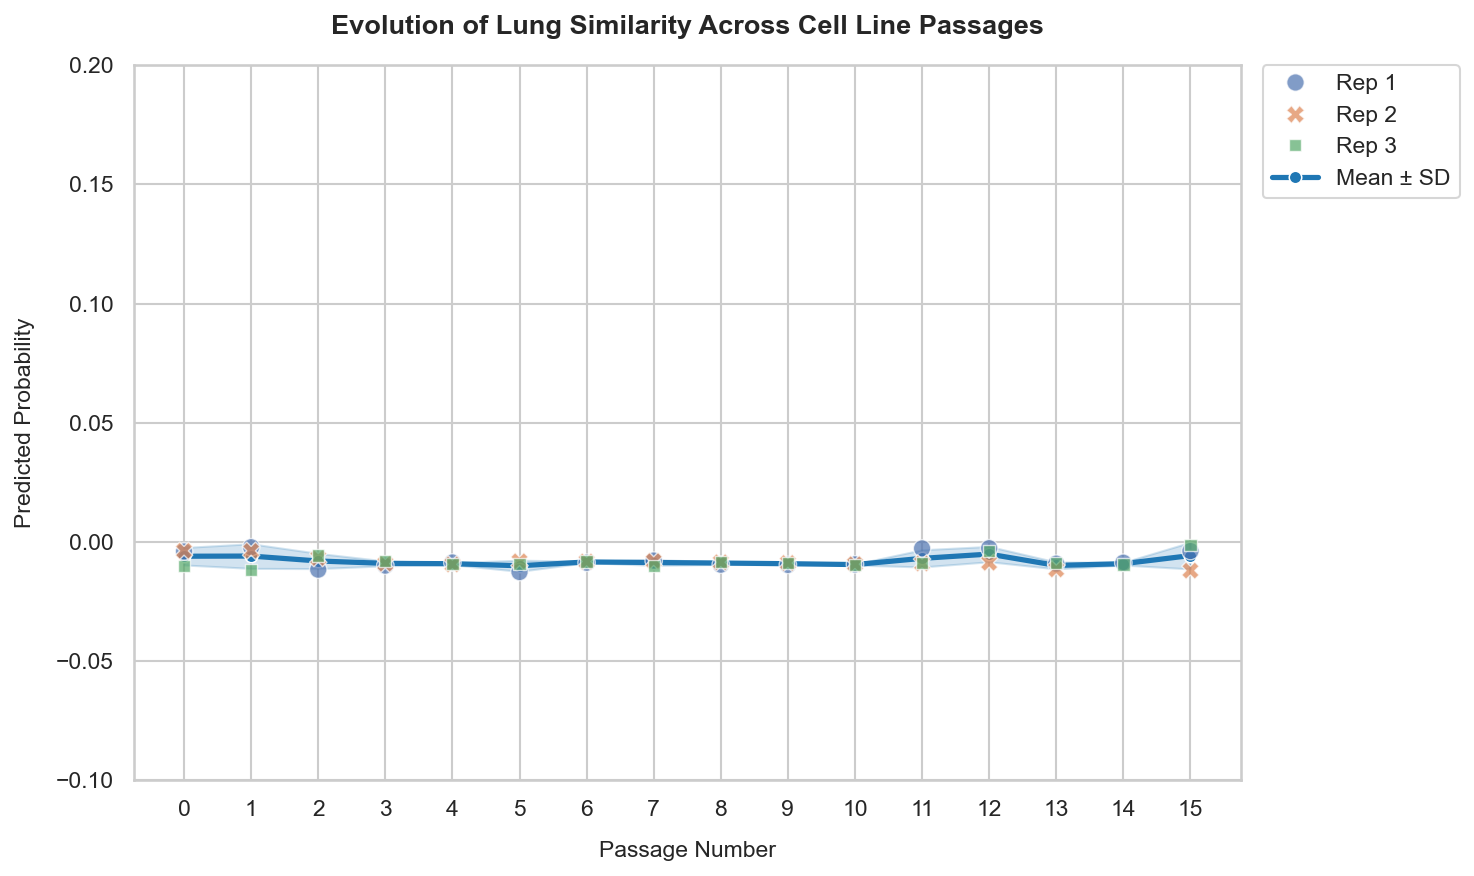

In [8]:
df_lung = df_predictions_long[df_predictions_long["Tissue"].str.lower() == "lung"].copy()

plt.figure(figsize=(10, 6), dpi=150)
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df_lung, x="Passage", y="Probability", hue="Replicate", style="Replicate",
    s=70, alpha=0.7, zorder=3,
)
sns.lineplot(
    data=df_lung, x="Passage", y="Probability", color="#1f77b4", linewidth=2.5,
    errorbar="sd", marker="o", markersize=6, label="Mean ± SD", zorder=2,
)

plt.title("Evolution of Lung Similarity Across Cell Line Passages", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Passage Number", fontsize=11, labelpad=10)
plt.ylabel("Predicted Probability", fontsize=11, labelpad=10)
plt.xticks(df_lung["Passage"].unique().astype(int))

# Custom y-axis ticks: -1.5 to 0.2 in steps of 0.05
plt.ylim(-0.1, 0.2)
plt.yticks(np.arange(-0.1, 0.2 + 0.05, 0.05))

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

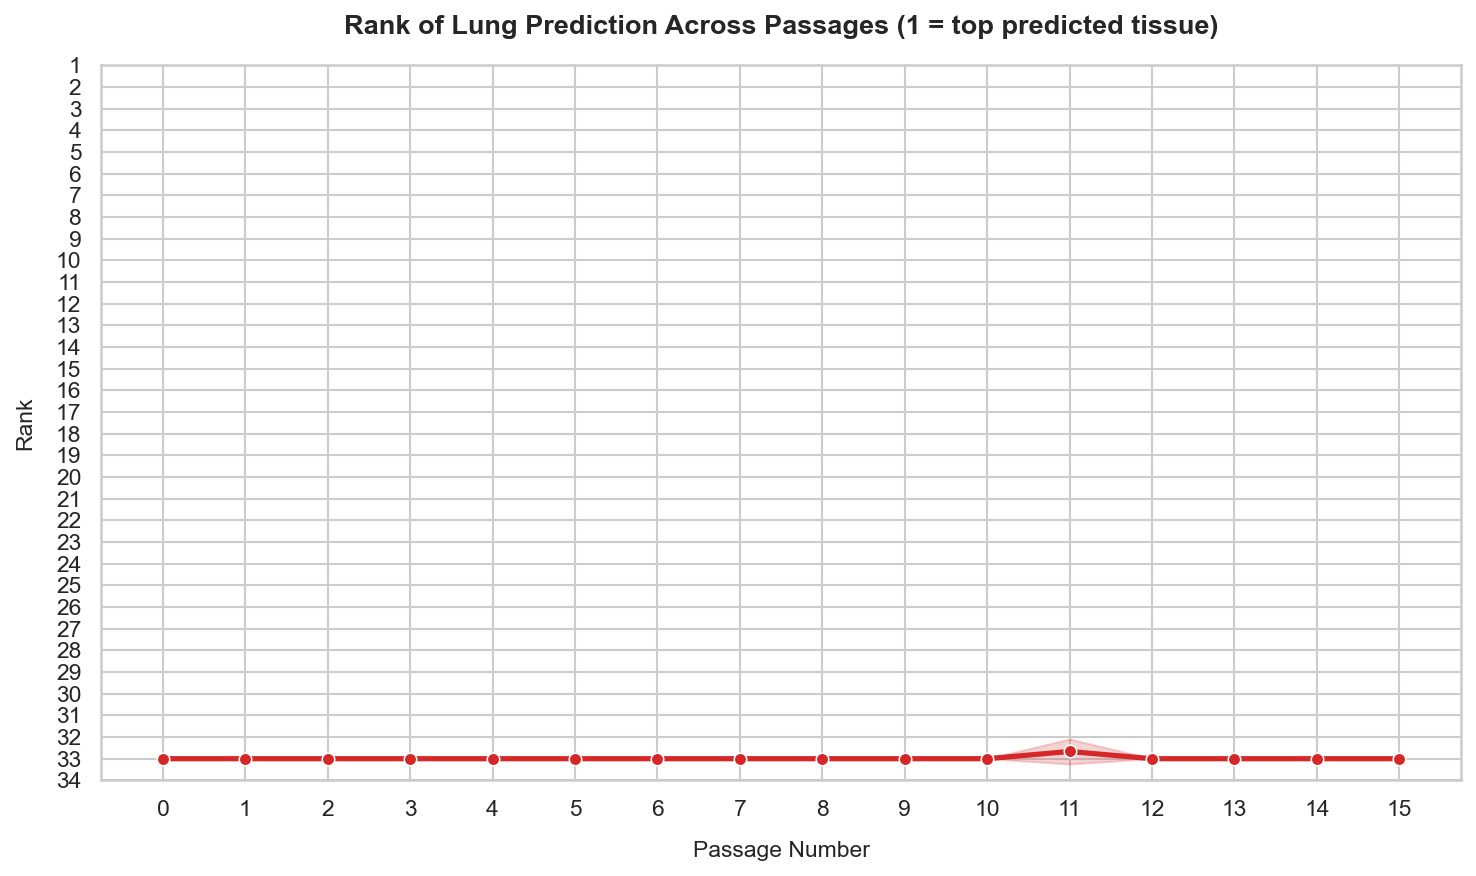

In [9]:
# Companion plot: Lung's RANK (1 = top prediction) across passages.
# This makes it obvious when/if another tissue (e.g. B-cell) overtakes Lung.
plt.figure(figsize=(10, 6), dpi=150)
sns.lineplot(
    data=df_lung, x="Passage", y="Rank", color="#d62728", linewidth=2.5,
    errorbar="sd", marker="o", markersize=6, zorder=2,
)

plt.ylim(1, 34)
plt.yticks(np.arange(1, 35, 1))  # 1, 2, 3, ..., 34
plt.gca().invert_yaxis()  # rank 1 at the top

plt.title("Rank of Lung Prediction Across Passages (1 = top predicted tissue)", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Passage Number", fontsize=11, labelpad=10)
plt.ylabel("Rank", fontsize=11, labelpad=10)
plt.xticks(df_lung["Passage"].unique().astype(int))
plt.tight_layout()
plt.show()

## 6. SHAP driver extraction


In [10]:
def get_top_bottom_shap(shap_results, tissue, n=N_SHAP_DRIVERS_EACH):
    """
    For each sample's SHAP dataframe, pull the n most negative and n most
    positive SHAP values for the given tissue row, and combine into one
    long-format summary dataframe.
    """
    summary_list = []

    for sample_id, df in shap_results.items():
        if tissue not in df.index:
            continue

        tissue_values = df.loc[tissue].sort_values()

        lowest_n = tissue_values.head(n)
        highest_n = tissue_values.tail(n)

        combined = pd.concat([lowest_n, highest_n])
        combined = combined[~combined.index.duplicated(keep="first")]

        sample_str = str(sample_id)
        parts = sample_str.split("_")

        raw_passage = int(parts[0])
        passage_num = raw_passage - 21
        replicate_id = int(parts[1]) if len(parts) > 1 else 1

        sample_summary = combined.to_frame(name="SHAP_Value")
        sample_summary["Sample_ID"] = sample_str
        sample_summary["Passage"] = passage_num
        sample_summary["Replicate"] = replicate_id
        sample_summary["Protein"] = sample_summary.index
        sample_summary["Tissue"] = tissue

        summary_list.append(sample_summary)

    if not summary_list:
        print(f"No data found for tissue '{tissue}'.")
        return pd.DataFrame()

    result_df = pd.concat(summary_list).reset_index(drop=True)
    result_df = result_df.sort_values(by=["Passage", "Replicate"]).reset_index(drop=True)
    result_df = result_df[["Sample_ID", "Passage", "Replicate", "Protein", "Tissue", "SHAP_Value"]]
    return result_df


# Lung drivers
final_summary_df = get_top_bottom_shap(shap_results, "Lung")
final_summary_df

,Sample_ID,Passage,Replicate,Protein,Tissue,SHAP_Value
0,21_1,0,1,P17661,Lung,-0.00401
1,21_1,0,1,Q14315,Lung,-0.00216
2,21_1,0,1,O14983,Lung,-0.00184
3,21_1,0,1,P35573,Lung,-0.00182
4,21_1,0,1,P13647,Lung,-0.00153
...,...,...,...,...,...,...
1875,36_3,15,3,Q9HBH5,Lung,0.00236
1876,36_3,15,3,A6NMZ7,Lung,0.00262
1877,36_3,15,3,Q13751,Lung,0.00262
1878,36_3,15,3,P48163,Lung,0.00350


In [11]:
# B-cell drivers, same structure as Lung
bcell_tissue_label = "B-cells"

final_summary_df_bcells = get_top_bottom_shap(shap_results, bcell_tissue_label)
final_summary_df_bcells

,Sample_ID,Passage,Replicate,Protein,Tissue,SHAP_Value
0,21_1,0,1,Q9BZQ8,B-cells,-0.00867
1,21_1,0,1,Q9Y678,B-cells,-0.00809
2,21_1,0,1,P54886,B-cells,-0.00601
3,21_1,0,1,P35580,B-cells,-0.00458
4,21_1,0,1,P09543,B-cells,-0.00450
...,...,...,...,...,...,...
1875,36_3,15,3,P12270,B-cells,0.01102
1876,36_3,15,3,A6NHR9,B-cells,0.01198
1877,36_3,15,3,Q9UQE7,B-cells,0.01264
1878,36_3,15,3,Q96SB8,B-cells,0.01449


In [12]:
# Parotid gland drivers, same structure as Lung
parotidgland_tissue_label = "Parotid gland"

final_summary_df_parotidgland = get_top_bottom_shap(shap_results, parotidgland_tissue_label)
final_summary_df_parotidgland

,Sample_ID,Passage,Replicate,Protein,Tissue,SHAP_Value
0,21_1,0,1,P35573,Parotid gland,-0.00548
1,21_1,0,1,P12273,Parotid gland,-0.00317
2,21_1,0,1,Q8TEM1,Parotid gland,-0.00289
3,21_1,0,1,P12270,Parotid gland,-0.00278
4,21_1,0,1,P13498,Parotid gland,-0.00265
...,...,...,...,...,...,...
1875,36_3,15,3,P14550,Parotid gland,0.00625
1876,36_3,15,3,P54886,Parotid gland,0.01025
1877,36_3,15,3,P46779,Parotid gland,0.01977
1878,36_3,15,3,Q9BZQ8,Parotid gland,0.03895
